## 1. Setup


In [ ]:
import os
import sys
from pathlib import Path

import pandas as pd
import pydata_google_auth
import pandas_gbq as pdq
from google.cloud.bigquery import magics
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.home() / "rule-metrics"

import importlib
import rule_metrics_functions as rm
importlib.reload(rm)

os.environ["GOOGLE_CLOUD_PROJECT"] = "dv-mkp-pmnt-sb"
PROJECT_ID = "dv-mkp-pmnt-sb"
MAX_BYTES_BILLED = 20_000_000_000


Set the needed data threshold below:

In [ ]:
EVALUATION_DATE_FROM = "2026-05-15"

In [ ]:
query_params = {"date_from": EVALUATION_DATE_FROM}

credentials = pydata_google_auth.get_user_credentials(
    ["https://www.googleapis.com/auth/cloud-platform","https://www.googleapis.com/auth/bigquery",],
    use_local_webserver=False,
)

magics.context.credentials = credentials
magics.context.project = PROJECT_ID

pdq.read_gbq(
    "select SESSION_USER()", project_id=PROJECT_ID, credentials=credentials,).head()
    
%load_ext google.cloud.bigquery


Downloading: 100%|██████████|


/Users/gabijastaponaite/Documents/GitHub/exp-metrics/.venv/lib/python3.12/site-packages/google/cloud/bigquery/__init__.py:237: FutureWarning: %load_ext google.cloud.bigquery is deprecated. Install bigquery-magics package and use `%load_ext bigquery_magics`, instead.
  warnings.warn(


## 2. Build source table


In [4]:
%%bigquery --params $query_params
CREATE OR REPLACE TABLE `dv-mkp-pmnt-sb.dev_gabija_staponaite.fct_fraud_rules2` AS
WITH base_data AS (
  SELECT
    b.payment_id,
    b.buyer_country_code,
    CAST(b.created_at AS DATE) AS evaluation_date,
    b.pay_in_amount_eur AS amount,
    
    -- Safe deduplicated array splitting
    ARRAY(SELECT DISTINCT TRIM(r) FROM UNNEST(SPLIT(b.matched_rules, ',')) AS r) AS rules_array,
    
    b.has_raised_payment_chargeback AS is_chargeback,
    a.three_d_secure_check_type,
    three_d_secure_check_status,
    CASE WHEN (b.fraud_type IS NOT NULL OR b.has_raised_payment_chargeback IS TRUE) THEN 1 ELSE 0 END AS is_fraud_total,
    CASE WHEN b.failure_reason IS NULL THEN 1 ELSE 0 END AS is_success,
    b.failure_reason
  FROM `vi-dv-prod-data.marts.mrt_fraud_engine_pay_ins` b
  LEFT JOIN (
    SELECT payment_id, three_d_secure_check_type , three_d_secure_check_status
    FROM `vi-dv-prod-data.marts.mrt_pay_ins`  
    WHERE payment_created_at > TIMESTAMP(@date_from)
      AND is_last_payment_per_transaction
    QUALIFY ROW_NUMBER() OVER(PARTITION BY payment_id ORDER BY payment_created_at DESC) = 1
  ) a ON a.payment_id = b.payment_id
  WHERE b.created_at > TIMESTAMP(@date_from)
    AND b.matched_rules IS NOT NULL
    AND b.is_last_payment_per_transaction
),

latest_rule_status AS (
  SELECT 
    TRIM(name) AS rule_name,
    action AS rule_status,
    event_time AS rule_last_update_at
  FROM `vi-dv-prod-raw-data.events.pay_fraud_engine_agent_entity_change`
  WHERE event_time > '2026-04-01'
    AND event_portal = 'svc_fraud_engine'
  QUALIFY ROW_NUMBER() OVER(PARTITION BY name ORDER BY event_time DESC) = 1
),

exploded_base AS (
  SELECT
    payment_id,
    evaluation_date,
    amount,
    buyer_country_code,
    is_chargeback,
    is_fraud_total,
    is_success,
    three_d_secure_check_type,
    three_d_secure_check_status,
    failure_reason,
    rule_name,
    CASE 
      WHEN rule_name LIKE '%_T' THEN '3DS'
      WHEN rule_name LIKE '%_M' THEN 'Alert & 3DS'
      WHEN rule_name LIKE '%_A' THEN 'Alert'
      WHEN rule_name LIKE '%_D' THEN 'Decline'
      ELSE 'Unknown'
    END AS rule_action,
    
    ARRAY_LENGTH(rules_array) AS total_rules_triggered_on_payment,
    CASE WHEN ARRAY_LENGTH(rules_array) = 1 THEN 1 ELSE 0 END AS is_sole_trigger,
    
    -- Decline Overlap: Just checks for other auto-declines
    CASE 
      WHEN EXISTS(SELECT 1 FROM UNNEST(rules_array) AS r WHERE r LIKE '%_D' AND r != rule_name) 
      THEN 1 ELSE 0 
    END AS has_decline_overlap,
    
    -- 3DS Overlap: Matches standalone 3DS (_T) AND combined Alert/3DS (_M)
    CASE 
      WHEN EXISTS(SELECT 1 FROM UNNEST(rules_array) AS r WHERE (r LIKE '%_T' OR r LIKE '%_M') AND r != rule_name) 
      THEN 1 ELSE 0 
    END AS has_3ds_overlap,
    
    -- Alert Overlap: Matches standalone Alerts (_A) AND combined Alert/3DS (_M)
    CASE 
      WHEN EXISTS(SELECT 1 FROM UNNEST(rules_array) AS r WHERE (r LIKE '%_A' OR r LIKE '%_M') AND r != rule_name) 
      THEN 1 ELSE 0 
    END AS has_alert_overlap,

    -- NEW METRIC: ML Rule Coverage Indicator
    CASE 
      WHEN EXISTS(
        SELECT 1 FROM UNNEST(rules_array) AS r 
        WHERE r IN ('F047_T','F061_T','F061_M','F037_T','F061_A','F037_A','F047_D')
          AND r != rule_name  -- Optional: prevents an ML rule from saying it overlaps with itself
      ) THEN 1 ELSE 0 
    END AS has_ml_overlap,

    CASE WHEN three_d_secure_check_status = 'unsupported' THEN 1 ELSE 0 END AS is_unsupported_3ds,
    rules_array
  FROM base_data,
  UNNEST(rules_array) AS rule_name
)

SELECT 
  e.*,
  COALESCE(r.rule_status, 'active') AS rule_status,
  CASE WHEN r.rule_status = 'destroy' THEN 0 ELSE 1 END AS is_active,
  COALESCE(r.rule_last_update_at, TIMESTAMP("2026-01-01")) AS rule_last_update_at
FROM exploded_base e
LEFT JOIN latest_rule_status r ON e.rule_name = r.rule_name

Query is running:   0%|          |

""


## 3. Load data


In [5]:
%%bigquery dt --use_rest_api --maximum_bytes_billed=20000000000 --params $query_params
SELECT *
FROM `dv-mkp-pmnt-sb.dev_gabija_staponaite.fct_fraud_rules2`
WHERE evaluation_date > @date_from


Query is running:   0%|          |

Downloading:   0%|          |

In [6]:
display(dt.head())
print(f"Rows: {len(dt):,} | Unique payments: {dt['payment_id'].nunique():,}")


,payment_id,evaluation_date,amount,buyer_country_code,is_chargeback,is_fraud_total,is_success,three_d_secure_check_type,three_d_secure_check_status,failure_reason,...,is_sole_trigger,has_decline_overlap,has_3ds_overlap,has_alert_overlap,has_ml_overlap,is_unsupported_3ds,rules_array,rule_status,is_active,rule_last_update_at
0,3454535608,2026-06-04,14.19,NL,False,0,0,None,None,Generic Error Y01,...,1,0,0,0,0,0,[A004_D],active,1,2026-01-01 00:00:00+00:00
1,3403118007,2026-05-20,44.64,NL,False,0,0,None,None,Generic Error Y01,...,1,0,0,0,0,0,[A004_D],active,1,2026-01-01 00:00:00+00:00
2,3399387565,2026-05-19,113.43,PL,False,0,0,None,None,Generic Error Y01,...,1,0,0,0,0,0,[A004_D],active,1,2026-01-01 00:00:00+00:00
3,3393021456,2026-05-17,20.21,GB,False,0,0,None,None,Generic Error Y01,...,1,0,0,0,0,0,[A004_D],active,1,2026-01-01 00:00:00+00:00
4,3470647353,2026-06-08,50.83,FR,False,0,0,None,None,Generic Error Y01,...,1,0,0,0,0,0,[A004_D],active,1,2026-01-01 00:00:00+00:00


Rows: 2,365,845 | Unique payments: 1,768,305


## 4. Compute metrics


In [7]:
dt2 = dt[dt["is_active"] == 1].copy()

In [8]:
rule_performance_matrix = rm.generate_rounded_rule_matrix(dt2)
audit_log_df = rm.run_rule_risk_audit(rule_performance_matrix)

print(f"Rules in matrix: {len(rule_performance_matrix):,}")
print(f"Audit exceptions: {len(audit_log_df):,}")


Rules in matrix: 65
Audit exceptions: 60


In [9]:
critical_only_df = audit_log_df[audit_log_df["level"] == "CRITICAL"]
rm.display_audit_exception_desk(critical_only_df, display, Markdown)

# 📋 System Audit Exception Desk

,rule_name,level,issue
0,F107_T,CRITICAL,High success rate: 95.66%
1,F011_A,CRITICAL,Low precision: (1.51%).
2,F081_A,CRITICAL,Low precision: (0.6%).
3,T001_A,CRITICAL,Low precision: (1.22%).
4,F133_T,CRITICAL,Liability Leak. 3DS bypass with a 0.59% charge...
5,F094_A,CRITICAL,Low precision: (0.78%).
6,F115_A,CRITICAL,Low precision: (0.0%).
7,F061_A,CRITICAL,Low precision: (1.26%).
8,F082_M,CRITICAL,High success rate: 98.36%
9,F131_M,CRITICAL,High success rate: 100.0%


In [31]:
import importlib
importlib.reload(rm)
rm.display_audit_criteria_reference(display, Markdown)

## 📏 Audit Criteria Reference

Rules are flagged when they breach any threshold below. **CRITICAL** issues need immediate review; **WARNING** issues signal tuning or monitoring needs.

level,applies_to,metric,threshold,description
CRITICAL,"3DS, Alert & 3DS",chargeback_rate,> 0.5%,Chargebacks occurring after 3DS challenge (liability leak).
CRITICAL,"3DS, Alert & 3DS",success_rate,> 95%,Very high pass-through rate; rule may be too permissive.
CRITICAL,"3DS, Alert & 3DS",unsupported_3ds_pct,> 30%,Large share of payments where 3DS is unsupported.
CRITICAL,"Alert, Alert & 3DS",precision_of_fraud,< 2%,Alert queue precision below acceptable baseline.
WARNING,"3DS, Alert & 3DS",precision_of_fraud,< 1%,Low fraud precision on 3DS challenge cohort.
WARNING,All actions,daily_trigger_rate,< 5 triggers/day,Rule fires too infrequently to assess reliably.
WARNING,All actions,overlap_with_ml_pct,> 50%,High co-trigger rate with ML model rules (possible redundancy).
WARNING,All actions,rule_last_update_at,> 180 days since last change,Rule logic has not been updated or reviewed in over 6 months.
WARNING,All actions,unique_trigger_pct,< 5%,Rule rarely fires alone; heavily overlaps with other rules.
WARNING,All actions,unique_trigger_pct,> 90%,Rule almost always fires in isolation; limited cross-rule coverage.


## 6. Cohort summaries by action


### Decline


In [32]:
rm.display_action_cohort_summary(
    "Decline",
    rule_performance_matrix,
    audit_log_df,
    display,
    Markdown,
    top_n=50,
)


---

## 📊 Decline Cohort Summary — 8 Registered Rules

🚨 **Advisory Note:** Found `0 Critical Exceptions` and `9 Warnings` requiring adjustments.

,Status,Issue_Details,daily_trigger_rate,precision_of_fraud,chargeback_rate,success_rate,unsupported_3ds_pct,technical_3ds_failure_pct,fraud_3ds_failure_pct,abandonment_3ds_pct,other_3ds_failure_pct,false_positive_contribution,unique_trigger_pct,overlap_with_decline_pct,overlap_with_3ds_pct,overlap_with_alert_pct,overlap_with_ml_pct,total_triggers,unique_payments,sole_triggers,total_fraud,total_cb,successful_payments,total_unsupported_3ds,total_technical_failures,total_fraud_failures,total_abandonments,total_other_failures,total_amount,min_date,max_date,days_of_evaluation,rule_last_update_at
rule_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A004_D,🟢 HEALTHY,Operating within limits.,"1,969.00",29.26%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,29.28%,38.13%,52.01%,1.11%,20.34%,47256,47223,13828,13817,0,0,0,47223,0,0,0,"2,335,504",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
A005_D,🟢 HEALTHY,Operating within limits.,708.29,37.32%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,9.84%,63.68%,63.06%,1.39%,25.44%,16999,16973,1670,6335,0,0,0,16973,0,0,0,"671,012",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
A006_D,🟢 HEALTHY,Operating within limits.,"1,059.86",24.73%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,10.35%,81.82%,40.33%,0.32%,9.11%,7419,7417,768,1834,0,0,0,7417,0,0,0,"178,135",2026-06-02,2026-06-08,7,2026-06-01 09:08:40.911000
F054_D,🟡 WARNING,Poor Precision (0.9%).,95.57,0.90%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,40.51%,19.73%,49.03%,2.99%,17.64%,669,669,271,6,0,0,0,669,0,0,0,"26,548",2026-06-02,2026-06-08,7,2026-06-01 07:11:11.437000
F047_D,🟡 WARNING,High overlap: only 0.5% unique footprint. | High ML Overlap: 96.98%.,33.17,15.58%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,0.50%,0.50%,87.94%,98.49%,96.98%,199,199,1,31,0,0,0,199,0,0,0,"12,714",2026-06-03,2026-06-08,6,2026-06-02 12:16:23.837000
F055_D,🟡 WARNING,Poor Precision (0.65%).,22.00,0.65%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,11.69%,55.19%,64.94%,11.69%,50.00%,154,154,18,1,0,0,0,154,0,0,0,"3,688",2026-06-02,2026-06-08,7,2026-06-01 07:11:25.742000
F120_D,🟡 WARNING,Poor Precision (2.67%). | Low trigger velocity: averages only 3.12 triggers/day.,3.12,2.67%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,28.00%,4.00%,57.33%,33.33%,36.00%,75,75,21,2,0,0,0,75,0,0,0,"342,130",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F119_D,🟡 WARNING,Poor Precision (2.33%). | Low trigger velocity: averages only 1.79 triggers/day. | Isolated logic: 100.0% unique footprint.,1.79,2.33%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,43,43,43,1,0,0,0,43,0,0,0,"64,353",2026-05-16,2026-06-08,24,2026-01-01 00:00:00


### 3DS


In [33]:
rm.display_action_cohort_summary(
    "3DS",
    rule_performance_matrix,
    audit_log_df,
    display,
    Markdown,
    top_n=50,
)


---

## 📊 3DS Cohort Summary — 22 Registered Rules

🚨 **Advisory Note:** Found `2 Critical Exceptions` and `7 Warnings` requiring adjustments.

,Status,Issue_Details,daily_trigger_rate,precision_of_fraud,chargeback_rate,success_rate,unsupported_3ds_pct,technical_3ds_failure_pct,fraud_3ds_failure_pct,abandonment_3ds_pct,other_3ds_failure_pct,false_positive_contribution,unique_trigger_pct,overlap_with_decline_pct,overlap_with_3ds_pct,overlap_with_alert_pct,overlap_with_ml_pct,total_triggers,unique_payments,sole_triggers,total_fraud,total_cb,successful_payments,total_unsupported_3ds,total_technical_failures,total_fraud_failures,total_abandonments,total_other_failures,total_amount,min_date,max_date,days_of_evaluation,rule_last_update_at
rule_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
F020_T,🟢 HEALTHY,Operating within limits.,"14,210.58",2.49%,0.00%,79.35%,0.50%,3.94%,2.25%,2.19%,11.75%,23.52%,67.04%,3.81%,31.82%,1.02%,9.74%,341054,341028,228623,8488,0,270594,1717,13445,7690,7458,40084,"19,069,738",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F018_T,🟢 HEALTHY,Operating within limits.,"10,215.50",2.45%,0.00%,61.14%,1.86%,4.51%,9.04%,10.71%,11.79%,13.03%,65.06%,4.29%,33.56%,1.83%,10.55%,245172,245156,159489,6016,7,149888,4550,11053,22162,26251,28905,"9,908,219",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F048_T,🟢 HEALTHY,Operating within limits.,"6,625.29",3.73%,0.00%,66.86%,0.11%,5.21%,2.96%,3.10%,21.21%,9.24%,21.72%,4.85%,78.17%,2.11%,25.29%,159007,158990,34529,5937,0,106307,173,8287,4703,4933,33721,"13,664,805",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F090_T,🟢 HEALTHY,Operating within limits.,"5,568.58",5.19%,0.00%,85.90%,0.04%,5.01%,1.96%,3.00%,3.79%,9.98%,52.47%,4.92%,47.17%,2.16%,7.47%,133646,133637,70113,6941,0,114789,50,6693,2614,4014,5060,"5,926,036",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F021_T,🟡 WARNING,Low Precision:(0.13%).,"4,744.25",0.13%,0.00%,90.79%,0.24%,1.77%,1.58%,2.14%,2.34%,8.99%,84.83%,1.73%,14.21%,0.30%,2.17%,113862,113861,96584,144,0,103373,268,2019,1799,2442,2669,"4,332,153",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F051_T,🟢 HEALTHY,Operating within limits.,"4,742.54",1.71%,0.00%,67.84%,0.05%,3.93%,2.50%,2.42%,22.30%,6.71%,34.80%,3.44%,64.87%,1.19%,22.45%,113821,113812,39605,1951,0,77206,55,4476,2840,2750,25383,"10,984,029",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F013_T,🟢 HEALTHY,Operating within limits.,"2,682.58",1.26%,0.00%,83.01%,0.54%,1.91%,4.43%,6.00%,2.75%,4.65%,35.24%,1.82%,64.70%,0.98%,7.21%,64382,64380,22689,810,0,53442,346,1230,2851,3862,1771,"1,984,382",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F116_T,🟢 HEALTHY,Operating within limits.,"2,301.50",1.99%,0.00%,68.78%,0.02%,3.32%,1.74%,1.36%,24.35%,3.30%,43.54%,3.15%,56.17%,0.22%,29.66%,55236,55233,24050,1099,0,37988,12,1836,959,751,13449,"1,906,612",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F037_T,🟢 HEALTHY,Operating within limits.,"6,392.17",2.23%,0.00%,40.29%,0.05%,11.19%,5.24%,4.34%,38.30%,1.34%,37.17%,10.76%,59.31%,4.42%,0.00%,38353,38351,14256,857,0,15452,18,4290,2011,1665,14690,"2,127,449",2026-06-03,2026-06-08,6,2026-06-02 08:28:12.538000


In [13]:
rm.plot_3ds_failure_distribution_bars(
    dt,
    target_actions=["3DS", "Alert & 3DS"],
    min_triggers=15)

### Alert


In [14]:
rm.plot_alert_precision_scatter_log(
    rule_performance_matrix,
    target_actions=["Alert", "Alert & 3DS"],
)


In [34]:
rm.display_action_cohort_summary(
    "Alert",
    rule_performance_matrix,
    audit_log_df,
    display,
    Markdown,
    top_n=50,
)


---

## 📊 Alert Cohort Summary — 12 Registered Rules

🚨 **Advisory Note:** Found `6 Critical Exceptions` and `5 Warnings` requiring adjustments.

,Status,Issue_Details,daily_trigger_rate,precision_of_fraud,chargeback_rate,success_rate,unsupported_3ds_pct,technical_3ds_failure_pct,fraud_3ds_failure_pct,abandonment_3ds_pct,other_3ds_failure_pct,false_positive_contribution,unique_trigger_pct,overlap_with_decline_pct,overlap_with_3ds_pct,overlap_with_alert_pct,overlap_with_ml_pct,total_triggers,unique_payments,sole_triggers,total_fraud,total_cb,successful_payments,total_unsupported_3ds,total_technical_failures,total_fraud_failures,total_abandonments,total_other_failures,total_amount,min_date,max_date,days_of_evaluation,rule_last_update_at
rule_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
F011_A,🔴 CRITICAL,Low precision: (1.51%).,248.58,1.51%,0.32%,98.31%,0.22%,0.10%,0.69%,0.18%,0.07%,0.51%,86.75%,0.05%,11.46%,3.92%,3.00%,5966,5964,5174,90,19,5863,13,6,41,11,4,"199,303",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F029_A,🟢 HEALTHY,Operating within limits.,153.21,2.15%,0.03%,94.56%,0.19%,0.54%,1.25%,0.52%,0.30%,0.30%,78.60%,0.14%,20.26%,7.42%,3.73%,3677,3677,2890,79,1,3477,7,20,46,19,11,"59,149",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F081_A,🔴 CRITICAL,Low precision: (0.6%).,138.29,0.60%,0.00%,88.76%,0.00%,0.03%,2.83%,1.02%,1.08%,0.26%,80.69%,0.00%,13.29%,2.92%,1.96%,3319,3319,2678,20,0,2946,0,1,94,34,36,"6,511,582",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
T001_A,🔴 CRITICAL,Low precision: (1.22%).,123.12,1.22%,0.00%,61.73%,0.00%,5.25%,3.76%,3.38%,25.79%,0.16%,47.38%,5.25%,44.60%,12.32%,24.06%,2955,2955,1400,36,0,1824,0,155,111,100,762,"1,218,903",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F037_A,🟢 HEALTHY,Operating within limits.,232.33,10.41%,0.00%,70.64%,11.56%,12.78%,6.75%,4.38%,1.44%,0.09%,37.19%,12.48%,60.98%,42.97%,43.69%,1394,1393,518,145,0,984,161,178,94,61,20,"57,631",2026-06-03,2026-06-08,6,2026-06-02 12:15:58.057000
F024_A,🟡 WARNING,High ML Overlap: 63.54%.,211.17,15.73%,0.08%,77.94%,2.53%,10.20%,4.58%,2.45%,1.19%,0.09%,36.44%,9.87%,63.54%,35.91%,63.54%,1267,1265,461,199,1,986,32,129,58,31,15,"109,306",2026-06-03,2026-06-08,6,2026-06-02 12:14:54.073000
F129_A,🟢 HEALTHY,Operating within limits.,45.67,4.11%,0.09%,95.80%,2.46%,1.09%,1.00%,0.46%,0.00%,0.09%,72.72%,0.91%,19.34%,18.98%,11.59%,1096,1096,797,45,1,1050,27,12,11,5,0,"50,998",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F094_A,🔴 CRITICAL,Low precision: (0.78%). | Isolated logic: 94.79% unique footprint.,32.00,0.78%,0.00%,90.49%,0.00%,0.13%,2.86%,0.00%,0.00%,0.06%,94.79%,0.00%,0.00%,5.21%,2.34%,768,768,728,6,0,695,0,1,22,0,0,"356,411",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F115_A,🔴 CRITICAL,Low precision: (0.0%).,21.79,0.00%,0.00%,77.63%,0.00%,13.38%,2.87%,4.78%,1.34%,0.04%,18.36%,4.97%,32.31%,58.70%,9.94%,523,523,96,0,0,406,0,70,15,25,7,"463,831",2026-05-16,2026-06-08,24,2026-01-01 00:00:00


### Alert & 3DS


In [35]:
rm.display_action_cohort_summary(
    "Alert & 3DS",
    rule_performance_matrix,
    audit_log_df,
    display,
    Markdown,
    top_n=50,
)


---

## 📊 Alert & 3DS Cohort Summary — 21 Registered Rules

🚨 **Advisory Note:** Found `2 Critical Exceptions` and `27 Warnings` requiring adjustments.

,Status,Issue_Details,daily_trigger_rate,precision_of_fraud,chargeback_rate,success_rate,unsupported_3ds_pct,technical_3ds_failure_pct,fraud_3ds_failure_pct,abandonment_3ds_pct,other_3ds_failure_pct,false_positive_contribution,unique_trigger_pct,overlap_with_decline_pct,overlap_with_3ds_pct,overlap_with_alert_pct,overlap_with_ml_pct,total_triggers,unique_payments,sole_triggers,total_fraud,total_cb,successful_payments,total_unsupported_3ds,total_technical_failures,total_fraud_failures,total_abandonments,total_other_failures,total_amount,min_date,max_date,days_of_evaluation,rule_last_update_at
rule_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
F126_M,🟢 HEALTHY,Operating within limits.,512.67,3.16%,0.00%,90.63%,21.71%,1.73%,3.29%,1.82%,1.37%,0.73%,77.38%,1.59%,19.35%,12.93%,10.10%,9228,9228,7141,292,0,8363,2003,160,304,168,126,"130,596",2026-05-22,2026-06-08,18,2026-05-21 14:03:33.395000
F014_M,🟢 HEALTHY,Operating within limits.,222.33,3.52%,0.04%,89.77%,10.93%,1.26%,4.05%,2.08%,1.01%,0.42%,70.11%,1.12%,23.33%,19.87%,10.81%,5336,5336,3741,188,2,4790,583,67,216,111,54,"80,487",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F118_M,🟡 WARNING,Low Precision:(0.41%).,123.10,0.41%,0.00%,91.96%,0.00%,0.00%,3.25%,1.38%,2.60%,0.10%,40.21%,0.00%,59.79%,2.52%,27.94%,1231,1231,495,5,0,1132,0,0,40,17,32,"35,693",2026-05-30,2026-06-08,10,2026-05-29 12:42:22.675000
F101_M,🟡 WARNING,High overlap: only 0.62% unique footprint.,47.33,14.46%,0.00%,35.98%,0.09%,12.87%,9.52%,10.23%,31.04%,0.04%,0.62%,11.53%,99.38%,5.46%,36.09%,1136,1134,7,164,0,408,1,146,108,116,352,"148,237",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F108_M,🟢 HEALTHY,Operating within limits.,32.92,13.92%,0.00%,74.68%,0.00%,14.94%,2.53%,1.39%,6.20%,0.05%,45.70%,14.94%,53.80%,0.00%,8.23%,790,790,361,110,0,590,0,118,20,11,49,"21,252",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F037_M,🟡 WARNING,High overlap: only 0.0% unique footprint. | High ML Overlap: 100.0%.,116.17,2.87%,0.00%,67.14%,0.00%,2.87%,12.05%,8.32%,8.03%,0.04%,0.00%,2.58%,100.00%,8.03%,100.00%,697,697,0,20,0,468,0,20,84,58,56,"49,446",2026-06-03,2026-06-08,6,2026-06-02 08:27:46.199000
F111_M,🟡 WARNING,Low Precision:(0.74%).,22.50,0.74%,0.00%,91.48%,0.37%,0.00%,2.41%,4.81%,1.11%,0.04%,38.89%,0.00%,61.11%,1.11%,25.74%,540,540,210,4,0,494,2,0,13,26,6,"15,873",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F102_M,🟢 HEALTHY,Operating within limits.,17.17,36.65%,0.00%,57.28%,0.49%,31.80%,3.40%,3.88%,3.64%,0.02%,15.78%,31.80%,84.22%,1.46%,16.26%,412,412,65,151,0,236,2,131,14,16,15,"50,383",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F096_M,🟡 WARNING,High overlap: only 0.0% unique footprint.,15.54,16.67%,0.00%,44.35%,0.00%,15.32%,12.90%,7.26%,19.62%,0.01%,0.00%,14.75%,100.00%,2.95%,40.75%,373,372,0,62,0,165,0,57,48,27,73,"78,382",2026-05-16,2026-06-08,24,2026-01-01 00:00:00


### Other / Unknown


In [36]:
rm.display_action_cohort_summary(
    "Unknown",
    rule_performance_matrix,
    audit_log_df,
    display,
    Markdown,
    top_n=50,
)


---

## 📊 Unknown Cohort Summary — 2 Registered Rules

🚨 **Advisory Note:** Found `0 Critical Exceptions` and `2 Warnings` requiring adjustments.

,Status,Issue_Details,daily_trigger_rate,precision_of_fraud,chargeback_rate,success_rate,unsupported_3ds_pct,technical_3ds_failure_pct,fraud_3ds_failure_pct,abandonment_3ds_pct,other_3ds_failure_pct,false_positive_contribution,unique_trigger_pct,overlap_with_decline_pct,overlap_with_3ds_pct,overlap_with_alert_pct,overlap_with_ml_pct,total_triggers,unique_payments,sole_triggers,total_fraud,total_cb,successful_payments,total_unsupported_3ds,total_technical_failures,total_fraud_failures,total_abandonments,total_other_failures,total_amount,min_date,max_date,days_of_evaluation,rule_last_update_at
rule_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
T001_B,🟡 WARNING,High ML Overlap: 51.04%.,60.00,4.58%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,31.11%,9.72%,66.04%,5.42%,51.04%,1440,1440,448,66,0,0,0,1440,0,0,0,"558,795",2026-05-16,2026-06-08,24,2026-01-01 00:00:00
F018_O,🟡 WARNING,High overlap: only 0.0% unique footprint.,14.71,1.13%,0.00%,91.50%,67.71%,0.28%,1.13%,1.13%,0.00%,0.03%,0.00%,0.00%,100.00%,9.07%,3.68%,353,353,0,4,0,323,239,1,4,4,0,"4,813",2026-05-16,2026-06-08,24,2026-01-01 00:00:00


## 7. Single rule check

### Country-level metrics for a rule

Styled metrics table by `buyer_country_code` for **`TARGET_RULE`** (post-update window only).


In [18]:
# Change this to inspect a different rule in sections 7–8
TARGET_RULE = "F107_T"

In [19]:
print(f"Country deep-dive for: {TARGET_RULE}")
rm.audit_rule_by_country(
    dt2,
    rule_name=TARGET_RULE,
    display=display,
    Markdown=Markdown,
)


Country deep-dive for: F107_T


## 🗺️ Country Deep-Dive Profile: `F107_T`

Evaluating operational window of **24 day(s)** from `2026-05-16` to `2026-06-08`.

,total_triggers,unique_payments,daily_trigger_rate,precision_of_fraud,chargeback_rate,success_rate,unique_trigger_pct,unsupported_3ds_pct,technical_3ds_failure_pct,fraud_3ds_failure_pct,abandonment_3ds_pct,other_3ds_failure_pct,total_amount
Country,,,,,,,,,,,,,
GB,"34,274","34,274","1,428.08",0.10%,0.00%,95.66%,60.85%,0.04%,0.06%,1.58%,2.07%,0.30%,"$4,195,623"


### Single-rule overlap analysis

Horizontal bar chart: other rules that co-triggered on the same payments as **`TARGET_RULE`**.


In [20]:
print(f"Overlap analysis for: {TARGET_RULE}")
rm.analyze_single_rule_overlap(
    dt2,
    target_rule=TARGET_RULE,
    display=display,
    Markdown=Markdown,
    min_shared_triggers=1,
)


Overlap analysis for: F107_T


## 🔍 Targeted Overlap Analysis: `F107_T`

Rule `F107_T` caught **34,274 unique payments** in total during its post-update window. The chart below shows which other rules fired on those same transactions:

## a. Overlap visualisations


In [21]:
rm.plot_interactive_heatmap_chunk(dt2, start_rank=0, end_rank=70)


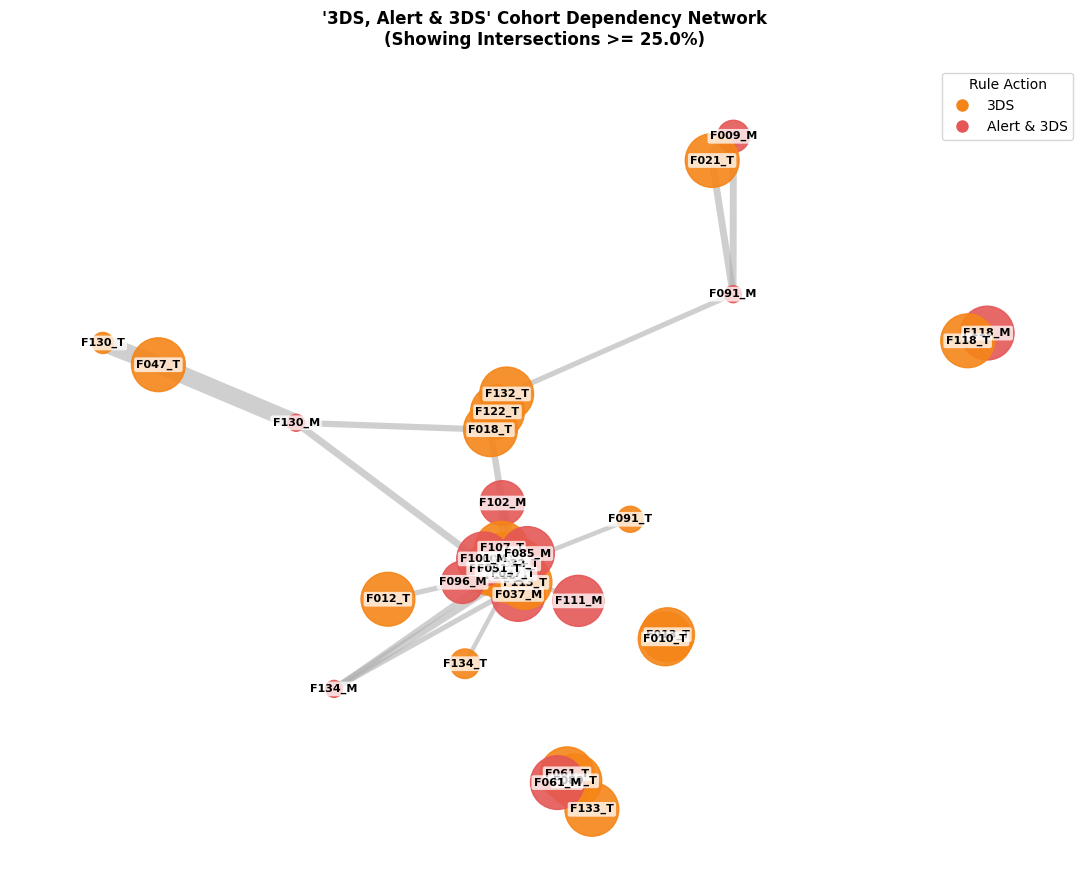

In [22]:
import importlib
importlib.reload(rm)

# All actions in one network (nodes colored by action type)
#rm.plot_cohort_network_graph(dt, target_actions=None, overlap_threshold_pct=25.0, min_triggers=10)

# Specific subset
rm.plot_cohort_network_graph(dt2, target_actions=["3DS", "Alert & 3DS"], overlap_threshold_pct=25.0, min_triggers=10)

## b. Rule deletion timeline

In [4]:
%%bigquery rule_events --use_rest_api --maximum_bytes_billed=20000000000 --params $query_params
SELECT
  TRIM(name) AS rule_name,
  action,
  event_time,
  event_portal
FROM `vi-dv-prod-raw-data.events.pay_fraud_engine_agent_entity_change`
WHERE event_portal = 'svc_fraud_engine'
  AND event_time > '2026-04-01'
ORDER BY rule_name, event_time

Query is running:   0%|          |

Downloading:   0%|          |

In [7]:
import plotly.express as px

events = rule_events

fig = px.scatter(
    events,
    x="event_time",
    y="rule_name",
    color="action",
    symbol="action",
    title="Rule adjustments over time (all events)",
    hover_data=["rule_name", "action", "event_time"],
    height=max(500, 25 * events["rule_name"].nunique()),
)
fig.update_traces(marker={"size": 10})
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()